1. Objective

The objective of this assignment is to perform Exploratory Data Analysis (EDA) on the Adult dataset to understand its structure, identify patterns, detect missing values, and extract meaningful insights related to income classification.

2. Dataset Description

The dataset contains demographic and employment-related information used to predict whether a person earns:

<=50K or >50K income annually
✔ Key Features:
Age
Workclass
Education
Occupation
Marital Status
Hours per week
Native country
Income (target variable)

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv('adult_with_headers.csv')

In [5]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
df.shape

(32561, 15)

In [7]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [9]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [11]:
df = df.drop_duplicates()

In [12]:
import matplotlib.pyplot as plt

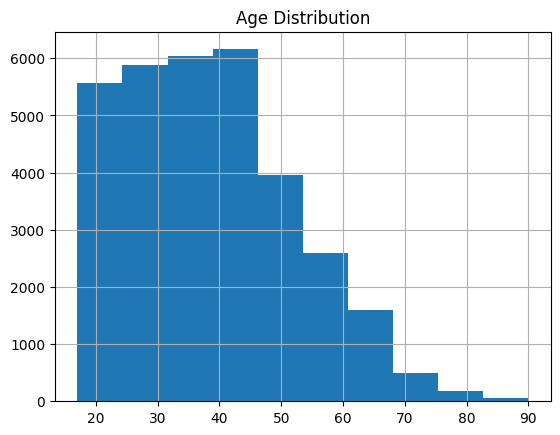

In [13]:
df['age'].hist()
plt.title("Age Distribution")
plt.show()

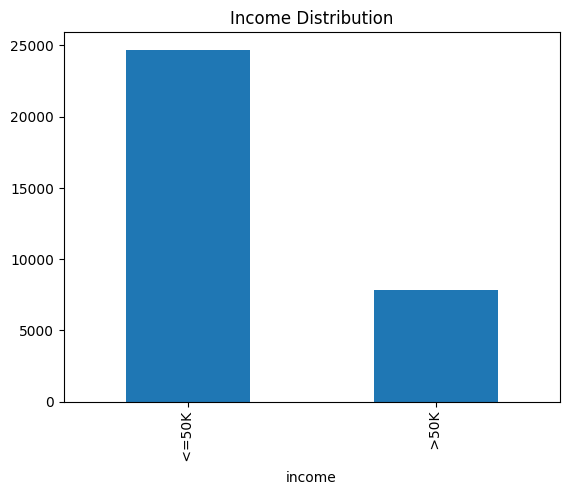

In [14]:
df['income'].value_counts().plot(kind='bar')
plt.title("Income Distribution")
plt.show()

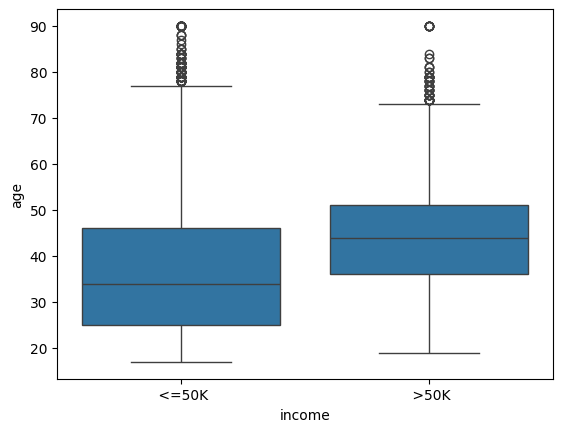

In [15]:
import seaborn as sns

sns.boxplot(x='income', y='age', data=df)
plt.show()

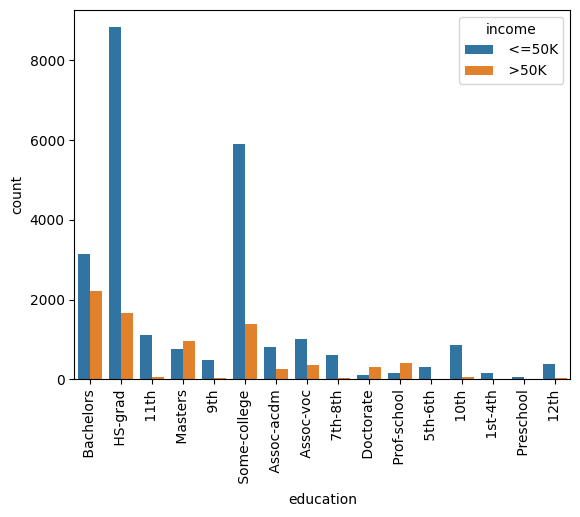

In [16]:
sns.countplot(x='education', hue='income', data=df)
plt.xticks(rotation=90)
plt.show()

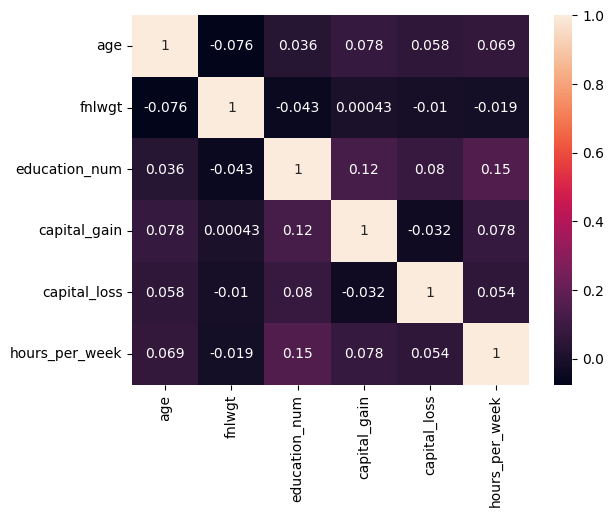

In [17]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

In [18]:



print(df.columns)

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='object')


In [19]:
df.columns = df.columns.str.strip()   

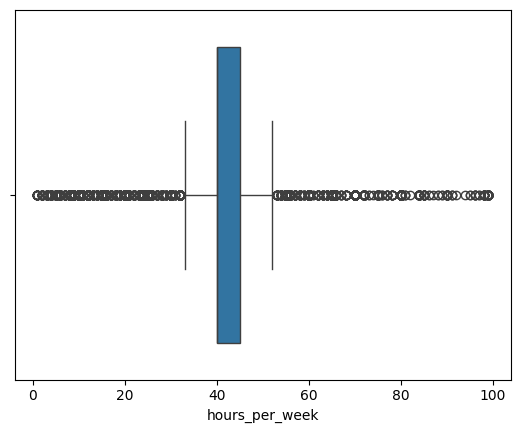

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['hours_per_week'])
plt.show()

Key Insights


Most individuals earn <=50K income
Age and income are positively related
Higher education levels tend to have higher income
Majority of people work around 40 hours/week
Some outliers exist in working hours and age
 12. Conclusion

The EDA performed on the Adult dataset helped in understanding the distribution of demographic and employment-related features. It revealed key factors influencing income such as age, education, and working hours. These insights are useful for further predictive modeling and decision-making.

# Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['age', 'fnlwgt']

df_scaled = df.copy()

df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

df_scaled.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030390,State-gov,-1.063569,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,0.836973,Self-emp-not-inc,-1.008668,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,-0.042936,Private,0.245040,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,1.056950,Private,0.425752,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,-0.776193,Private,1.408066,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Feature scaling standardizes numerical columns so that all features contribute equally to machine learning algorithms.
StandardScaler converts data into a standard normal distribution with mean 0 and standard deviation 1.

# Encoding Categorical Variables

In [23]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_cols = df.select_dtypes(include='object').columns

df_encoded = df.copy()

for col in categorical_cols:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

df_encoded.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0


Encoding converts categorical data into numerical form so that machine learning models can process the dataset effectively.
Label Encoding was used for transforming categorical features.

# Feature Engineering

In [28]:
print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'age_group']


In [29]:
df['capital_diff'] = df['capital_gain'] - df['capital_loss']

In [30]:
df[['age','age_group','capital_gain','capital_loss','capital_diff']].head()

,age,age_group,capital_gain,capital_loss,capital_diff
0,39,Adult,2174,0,2174
1,50,Senior,0,0,0
2,38,Adult,0,0,0
3,53,Senior,0,0,0
4,28,Adult,0,0,0


In [31]:
# Check columns
print(df.columns)

# Create Age Group Feature
df['age_group'] = pd.cut(df['age'],
                         bins=[0,25,45,65,100],
                         labels=['Young','Adult','Senior','Old'])

# Create Capital Difference Feature
df['capital_diff'] = df['capital_gain'] - df['capital_loss']

# Display result
df[['age','age_group','capital_gain','capital_loss','capital_diff']].head()

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income', 'age_group', 'capital_diff'],
      dtype='object')


,age,age_group,capital_gain,capital_loss,capital_diff
0,39,Adult,2174,0,2174
1,50,Senior,0,0,0
2,38,Adult,0,0,0
3,53,Senior,0,0,0
4,28,Adult,0,0,0


# Isolation Forest for Outlier Detection

In [32]:
from sklearn.ensemble import IsolationForest

# Selecting numerical columns
numeric_cols = df_encoded.select_dtypes(include=['int64','float64'])

# Isolation Forest Model
iso = IsolationForest(contamination=0.05, random_state=42)

# Predicting outliers
df_encoded['outlier'] = iso.fit_predict(numeric_cols)

# Display counts
df_encoded['outlier'].value_counts()

outlier
 1    30910
-1     1627
Name: count, dtype: int64

Isolation Forest is an anomaly detection algorithm used to identify unusual observations or outliers in the dataset.

The model isolates anomalies instead of profiling normal data points, making it efficient for large datasets.

# Predictive Power Score (PPS) Analysis

In [34]:
!pip install ppscore

In [35]:
import ppscore as pps

# PPS Matrix
pps_matrix = pps.matrix(df)

pps_matrix.head()

C:\Users\aryaa\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\aryaa\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\aryaa\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\aryaa\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\aryaa\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=4.
  warnings.warn(
C:\Users\aryaa\anaconda3\Lib\s

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.000000,predict_itself,True,None,0.000000,1.000000,None
1,age,workclass,0.020900,classification,True,weighted F1,0.581447,0.590195,DecisionTreeClassifier()
2,age,fnlwgt,0.000000,regression,True,mean absolute error,75736.243800,77225.235712,DecisionTreeRegressor()
3,age,education,0.061247,classification,True,weighted F1,0.189800,0.239423,DecisionTreeClassifier()
4,age,education_num,0.000000,regression,True,mean absolute error,1.865200,1.906863,DecisionTreeRegressor()


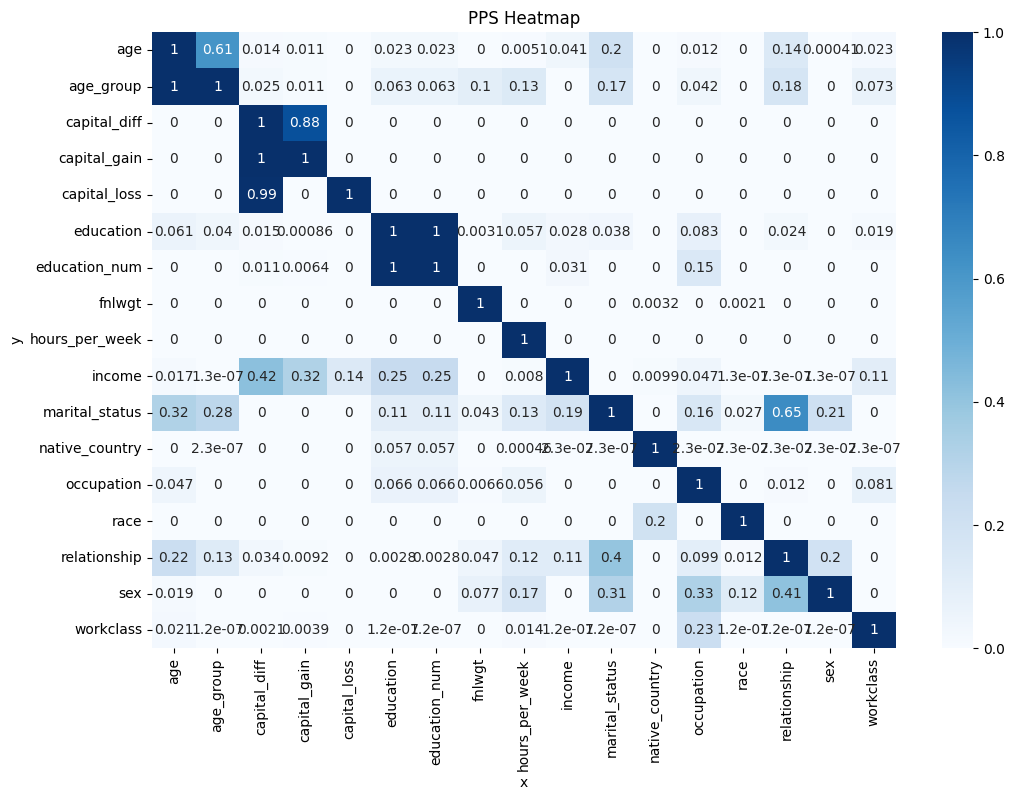

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot PPS matrix
matrix_df = pps_matrix.pivot(columns='x', index='y', values='ppscore')

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(matrix_df, annot=True, cmap='Blues')

plt.title("PPS Heatmap")
plt.show()

Predictive Power Score (PPS) measures the predictive relationship between variables.

Unlike correlation, PPS can identify both linear and non-linear relationships between features.

# Conclusion

The Adult dataset was analyzed using various Exploratory Data Analysis techniques including visualization, scaling, encoding, feature engineering, anomaly detection, and PPS analysis.

These techniques improved understanding of the dataset and prepared the data for future machine learning tasks.